# 1. Разведывательный анализ данных (EDA)

Данный ноутбук содержит разведывательный анализ датасета MovieLens 32M.

## 1.1. Импорт библиотек и загрузка путей

In [1]:
import json
import urllib
import zipfile
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from mrh.utils import load_json
from mrh.data import download_data, extract_archive

C:\something\aie\aie-shishova\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd().parent
paths_path = PROJECT_ROOT / 'configs/paths.json'

paths = load_json(paths_path)

## 1.2. Скачивание и извлечение данных

In [8]:
data_url = paths['data_url']
data_dir = PROJECT_ROOT / paths['data_dir']
data_raw_dir = PROJECT_ROOT / paths['data_raw_dir']
ml_32m_zip = data_raw_dir / paths['ml_32m_zip']
download_data(url=data_url, path=ml_32m_zip)

In [9]:
ml_32m = data_raw_dir / paths['ml_32m']
extract_archive(path_from=ml_32m_zip, directory=data_raw_dir, expected_path=ml_32m)

## 1.3. Анализ файлов ratings.csv, movies.csv и tags.csv

In [10]:
ratings_path = ml_32m / paths['ratings_path']
movies_path = ml_32m / paths['movies_path']
tags_path = ml_32m / paths['tags_path']

In [11]:
def analyse_df_by_path(df_path):
    """
    Общий анализ csv файла.
    Выводит:
        - первые пять строк;
        - последние пять строк;
        - размер;
        - описание числовых столбцов;
        - количество пустых значений;
        - количество дубликатов.
    """
    if not str(df_path).lower().endswith('.csv'):
        print(f'Предупреждение: файл "{df_path}" имеет расширение не .csv')
    
    if not Path(df_path).exists():
        print(f'Ошибка: файл "{df_path}" не найден!')
        return None
    
    print('Путь:', df_path)
    
    try:
        df = pd.read_csv(df_path)
    except Exception as e:
        print(f'Ошибка загрузки: {e}')
        return None
    
    print()
    print('Первые пять строк:')
    display(df.head())
    print('\nПоследние пять строк:')
    display(df.tail())
    print(f'\nФорма: {df.shape}')
    print('\nОписание:')
    display(df.describe())
    print(f'\nКоличество пустых значений: {np.sum(df.isnull())}')
    print(f'\nКоличество дубликатов: {np.sum(df.duplicated())}\n\n')
    return df

In [12]:
ratings = analyse_df_by_path(ratings_path)

Путь: C:\something\aie\aie-shishova\project\data\raw\ml-32m\ratings.csv

Первые пять строк:


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858



Последние пять строк:


,userId,movieId,rating,timestamp
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800
32000203,200948,87304,4.5,1350423523



Форма: (32000204, 4)

Описание:


,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09



Количество пустых значений: 0

Количество дубликатов: 0




In [13]:
movies = analyse_df_by_path(movies_path)

Путь: C:\something\aie\aie-shishova\project\data\raw\ml-32m\movies.csv

Первые пять строк:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Последние пять строк:


,movieId,title,genres
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama
87584,292757,Race to the Summit (2023),Action|Adventure|Documentary



Форма: (87585, 3)

Описание:


,movieId
count,87585.000000
mean,157651.365519
std,79013.402099
min,1.000000
25%,112657.000000
50%,165741.000000
75%,213203.000000
max,292757.000000



Количество пустых значений: 0

Количество дубликатов: 0




In [14]:
tags = analyse_df_by_path(tags_path)

Путь: C:\something\aie\aie-shishova\project\data\raw\ml-32m\tags.csv

Первые пять строк:


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102



Последние пять строк:


,userId,movieId,tag,timestamp
2000067,162279,90645,Rafe Spall,1320817734
2000068,162279,91079,Anton Yelchin,1322337407
2000069,162279,91079,Felicity Jones,1322337400
2000070,162279,91658,Rooney Mara,1325828398
2000071,162279,100714,Julie Delpy,1373095449



Форма: (2000072, 4)

Описание:


,userId,movieId,timestamp
count,2.000072e+06,2.000072e+06,2.000072e+06
mean,8.192859e+04,7.189326e+04,1.528914e+09
std,3.810650e+04,7.480379e+04,1.290835e+08
min,2.200000e+01,1.000000e+00,1.135429e+09
25%,6.841300e+04,4.011000e+03,1.473615e+09
50%,7.821300e+04,5.232800e+04,1.574071e+09
75%,1.036980e+05,1.222940e+05,1.614740e+09
max,1.622790e+05,2.926290e+05,1.697155e+09



Количество пустых значений: 17

Количество дубликатов: 0




In [15]:
tags[tags.isna().any(axis=1)]

,userId,movieId,tag,timestamp
185377,27046,33826,NaN,1221450908
1394089,89369,281500,NaN,1670942104
1914668,153443,123,NaN,1199450867
1914669,153443,346,NaN,1199451946
1914673,153443,1184,NaN,1199452261
1914680,153443,1785,NaN,1199452006
1914681,153443,2194,NaN,1199450677
1914683,153443,2691,NaN,1199451002
1914691,153443,4103,NaN,1199451920
1914693,153443,4473,NaN,1199451040


Данные содержат три ключевых файла: ratings.csv, movies.csv и tags.csv.

- ratings.csv - рейтинги пользователей, поставленные соответствующим фильмам. Дубликатов нет, как и пустых значений. Состоит из 32 000 204 уникальных взаимодействий, каждая из которых содержит четыре поля:
    - userId - id пользователя;
    - movieId - id фильма;
    - rating - оценка фильма пользователем, вещественное число от 0.5 до 5.0;
    - timestamp - временная метка о действии.
- movies.csv - информация о фильмах. Дубликатов нет, как и пустых строк. Состоит из 87585 уникальных фильмов; каждый фильм имеет три поля:
    - movieId - id фильма;
    - title - название фильма, рядом с ним почти всегда располагается год выпуска;
    - genres - жанры фильма, полный список жанров указан в README.txt к данным.
- tags.csv - информация о тегах, поставленных пользователями фильмам. Дубликатов нет, но обнаружено 17 пустых значений в поле tag. Состоит из 2000072 взаимодействий, каждому из которых соответствует:
    - userId - id пользователя;
    - movieId - id фильма;
    - tag - тег, указанный пользователем конкретному фильму;
    - timestamp - временная метка о действии.

In [16]:
print(f'Количество уникальных пользователей: {len(set(ratings['userId']))}')
print(f'Количество уникальных фильмов: {movies.shape[0]}')

Количество уникальных пользователей: 200948
Количество уникальных фильмов: 87585


In [17]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = pd.to_numeric(movies['year'], errors='coerce').astype('Int64')
print(f'Количество фильмов без года: {np.sum(movies['year'].isna())}')
decs = np.ceil((movies['year'].max() - movies['year'].min()) / 10).astype(int)
print(f'Количество десятилетий: {decs}')
movies['year'].describe()

Количество фильмов без года: 615
Количество десятилетий: 15


count        86970.0
mean     1995.354226
std        26.011089
min           1874.0
25%           1981.0
50%           2006.0
75%           2015.0
max           2023.0
Name: year, dtype: Float64

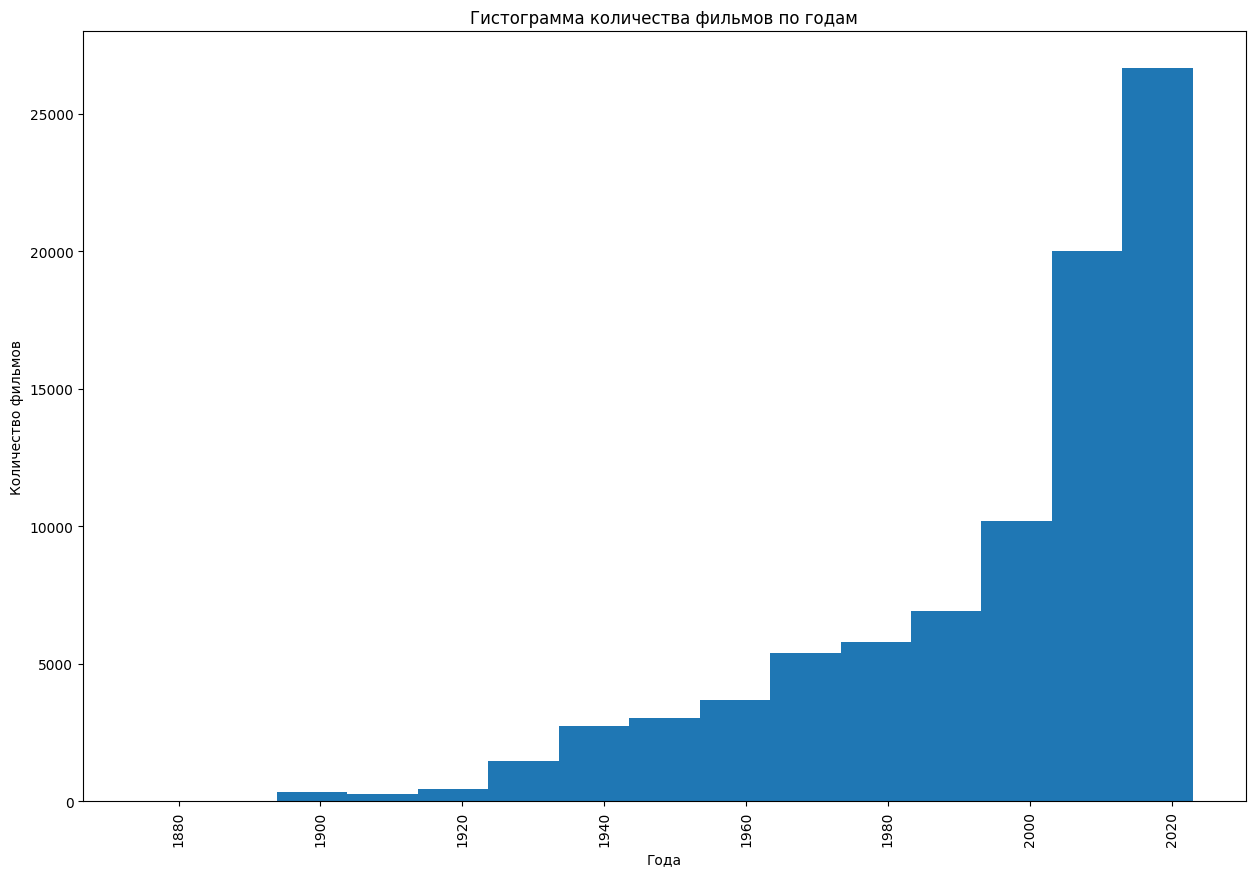

In [18]:
artifacts_dir = PROJECT_ROOT / paths['artifacts_dir']
notebook_artifacts_dir = artifacts_dir / paths['notebooks_artifacts_dir']
hist_movie_year_plot_path = notebook_artifacts_dir / paths['hist_movie_year_plot']
hist_movie_year_plot_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(15, 10))
ax.hist(movies.loc[~movies['year'].isna(), 'year'], bins=decs)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Гистограмма количества фильмов по годам')
ax.set_ylabel('Количество фильмов')
ax.set_xlabel('Года')
plt.savefig(hist_movie_year_plot_path)
plt.show()

Год выпуска фильма вынесен в отдельное поле. Гистограмма количества фильмов по годам выпуска показывает, что со временем фильмов, с которыми взаимодействуют пользователи, становится все больше. Предполагается, что это связано с ростом производства фильмов.

Всего уникальных пользователей 200948, а уникальных фильмов 87585.